# Week 2 Lab (Part 2): Delay Discounting

Fit discounting models to participant indifference points and compare them.

- Hyperbolic (Mazur): $V = A / (1 + kD)$
- Hyperboloid (Rachlin): $V = A / (1 + kD^{s})$
- Area Under the Curve (AUC): a model-free index of discounting

Each row of `participant_data.csv` is one participant's indifference points across
seven delays for a given Amount and Commodity. Fit the models, then look for trends
in discounting across amount, commodity, and gain vs. loss.

## Setup

Import `numpy`, `pandas`, plotting libraries, `curve_fit` from `scipy.optimize`, `simpson` from `scipy.integrate` (for AUC), and `r2_score`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.integrate import simpson
from sklearn.metrics import r2_score

## Task 1: Load and reshape the data

Load `participant_data.csv` and melt the `delay_*` columns into long form, with one row per (participant, amount, commodity, delay). Convert the delay labels to integers.

In [2]:
df = pd.read_csv("participant_data.csv")
df = df.melt(id_vars=['participant_id', 'Amount', 'Commodity'],
             var_name='delay', value_name='indifference_point')
df['delay'] = df['delay'].str.replace('delay_', '').astype(int)
df

,participant_id,Amount,Commodity,delay,indifference_point
0,1,100,Money,0,87.046932
1,2,100,Money,0,89.177107
2,3,100,Money,0,91.276222
3,4,100,Money,0,91.486833
4,5,100,Money,0,77.974339
...,...,...,...,...,...
2795,96,100,Money Loss,730,48.793758
2796,97,100,Money Loss,730,29.562199
2797,98,100,Money Loss,730,51.186185
2798,99,100,Money Loss,730,41.575091


## Task 2: Define the discounting models

Write the hyperbolic and hyperboloid functions.

In [ ]:
# Hyperbolic: V = A / (1 + kD)
def hyperbolic(D, A, k):
    return A / (1 + k * D)

# Hyperboloid: V = A / (1 + kD^s))
def hyperboloid(D, A, k, s):
    return A / (1 + k * (D ** s))

## Task 3: Fit both models and compute AUC

Loop over each (participant, amount, commodity) group. Fit the hyperbolic and hyperboloid models with `curve_fit` (holding `A` fixed at the task amount), record the recovered parameters and R-squared, and compute AUC on normalized delays and values.

In [4]:
fit_results = []

for (pid, amount, commodity), group in df.groupby(['participant_id', 'Amount', 'Commodity']):
    D = group['delay'].values
    V = group['indifference_point'].values
    A = amount

    # Hyperbolic
    try:
        popt_hyp, _ = curve_fit(lambda D, k: hyperbolic(D, A, k), D, V, bounds=(0, [10]))
        k_fit = popt_hyp[0]
        r2_hyp = r2_score(V, hyperbolic(D, A, k_fit))
    except Exception:
        k_fit, r2_hyp = np.nan, np.nan

    # Hyperboloid
    try:
        popt_hypb, _ = curve_fit(lambda D, k, s: hyperboloid(D, A, k, s), D, V,
                                 bounds=([0, 0], [10, 1]))
        k_fit_b, s_fit_b = popt_hypb
        r2_hypb = r2_score(V, hyperboloid(D, A, k_fit_b, s_fit_b))
    except Exception:
        k_fit_b, s_fit_b, r2_hypb = np.nan, np.nan, np.nan

    # AUC on normalized delay/value
    norm_D = (D - D.min()) / (D.max() - D.min()) if D.max() > D.min() else D
    norm_V = V / A
    auc = simpson(norm_V, norm_D)

    fit_results.append({'participant_id': pid, 'Amount': amount, 'Commodity': commodity,
                        'k_hyperbolic': k_fit, 'k_hyperboloid': k_fit_b, 's_hyperboloid': s_fit_b,
                        'AUC': auc, 'r2_hyperbolic': r2_hyp, 'r2_hyperboloid': r2_hypb})

fit_df = pd.DataFrame(fit_results)
fit_df

,participant_id,Amount,Commodity,k_hyperbolic,k_hyperboloid,s_hyperboloid,AUC,r2_hyperbolic,r2_hyperboloid
0,1,100,Food,0.006209,0.411217,0.171239,0.455352,0.276658,0.858442
1,1,100,Money,0.004470,0.243959,0.169452,0.500882,0.336458,0.847276
2,1,100,Money Loss,0.005719,0.363023,0.170630,0.466354,0.289018,0.855785
3,1,1000,Money,0.001745,0.440766,0.090551,0.649310,0.234344,0.997350
4,2,100,Food,0.004354,10.000000,0.087563,0.489220,-1.108751,0.601088
...,...,...,...,...,...,...,...,...,...
395,99,1000,Money,0.001957,1.094573,0.080909,0.636387,-0.032924,0.992825
396,100,100,Food,0.003644,2.178259,0.098915,0.550732,-0.286106,0.886483
397,100,100,Money,0.002690,1.145792,0.096527,0.593191,-0.183755,0.871233
398,100,100,Money Loss,0.003363,1.839948,0.098348,0.561569,-0.263765,0.882749


## Task 4: Write a helper to plot fits

Create a function that plots observed indifference points with the fitted hyperbolic and hyperboloid curves for a sample of participants in a chosen commodity/amount.

In [5]:
def plot_discounting_fits(df, fit_df, commodity, amount, n_participants=6, random_seed=42):
    all_pids = fit_df[(fit_df['Commodity'] == commodity) &
                      (fit_df['Amount'] == amount)]['participant_id'].unique()
    if len(all_pids) < n_participants:
        n_participants = len(all_pids)
    np.random.seed(random_seed)
    pids = np.random.choice(all_pids, size=n_participants, replace=False)

    plt.figure(figsize=(15, 8))
    for i, pid in enumerate(pids):
        group = df[(df['participant_id'] == pid) & (df['Commodity'] == commodity) &
                   (df['Amount'] == amount)]
        D, V, A = group['delay'].values, group['indifference_point'].values, group['Amount'].iloc[0]
        fr = fit_df[(fit_df['participant_id'] == pid) & (fit_df['Commodity'] == commodity) &
                    (fit_df['Amount'] == amount)]
        k_h, k_b, s_b = fr['k_hyperbolic'].values[0], fr['k_hyperboloid'].values[0], fr['s_hyperboloid'].values[0]

        plt.subplot(2, 3, i + 1)
        plt.scatter(D, V, label='Data')
        if not np.isnan(k_h):
            plt.plot(D, hyperbolic(D, A, k_h), label='Hyperbolic', linestyle='--')
        if not np.isnan(k_b) and not np.isnan(s_b):
            plt.plot(D, hyperboloid(D, A, k_b, s_b), label='Hyperboloid', linestyle=':')
        plt.title(f'P{pid}, {commodity}, {amount}')
        plt.xlabel('Delay'); plt.ylabel('Value'); plt.legend()
    plt.tight_layout()
    plt.show()

## Task 5: Plot fits across tasks

Use the helper to inspect fits for a few commodity/amount combinations, including a gain and a loss.

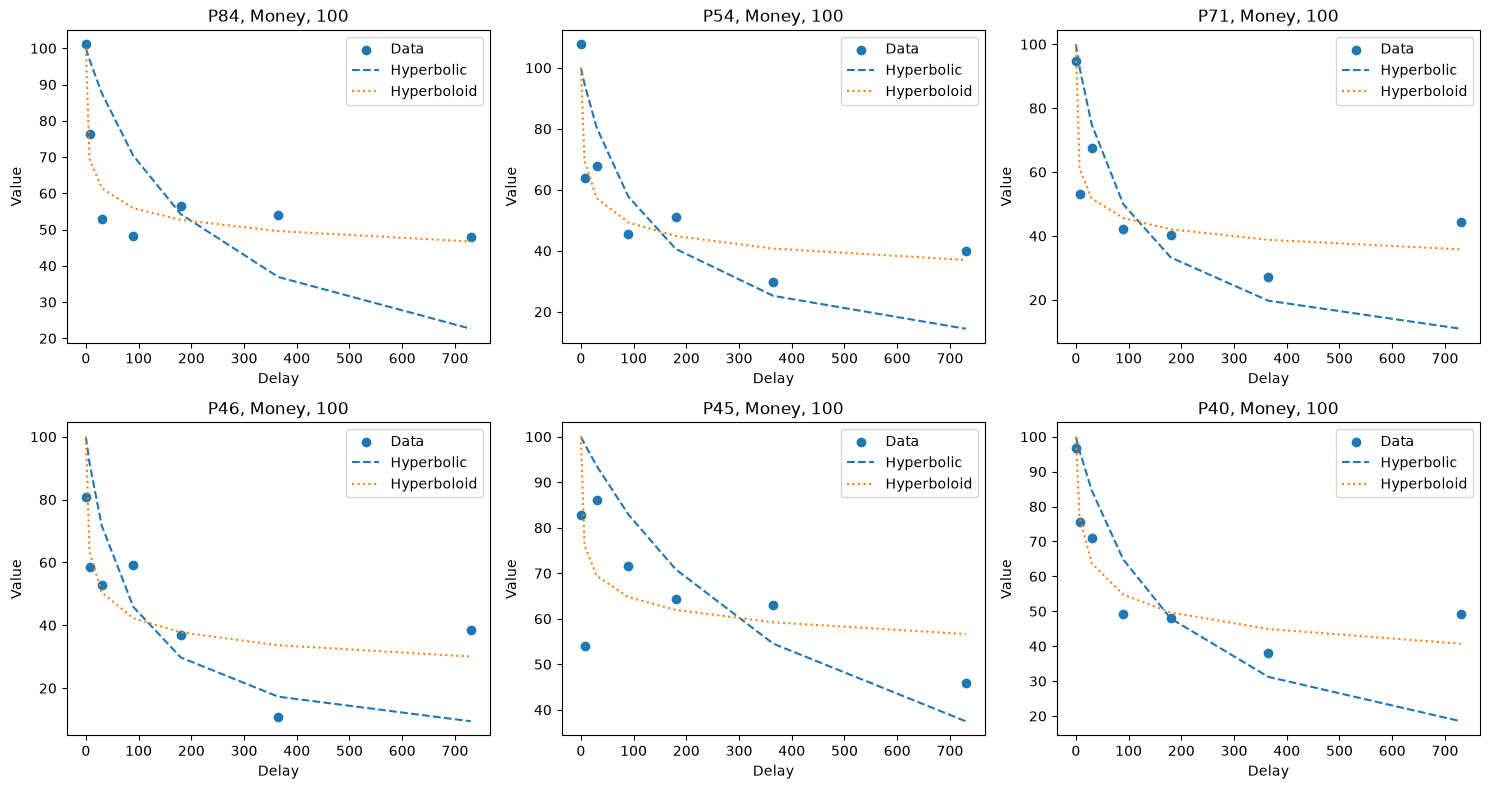

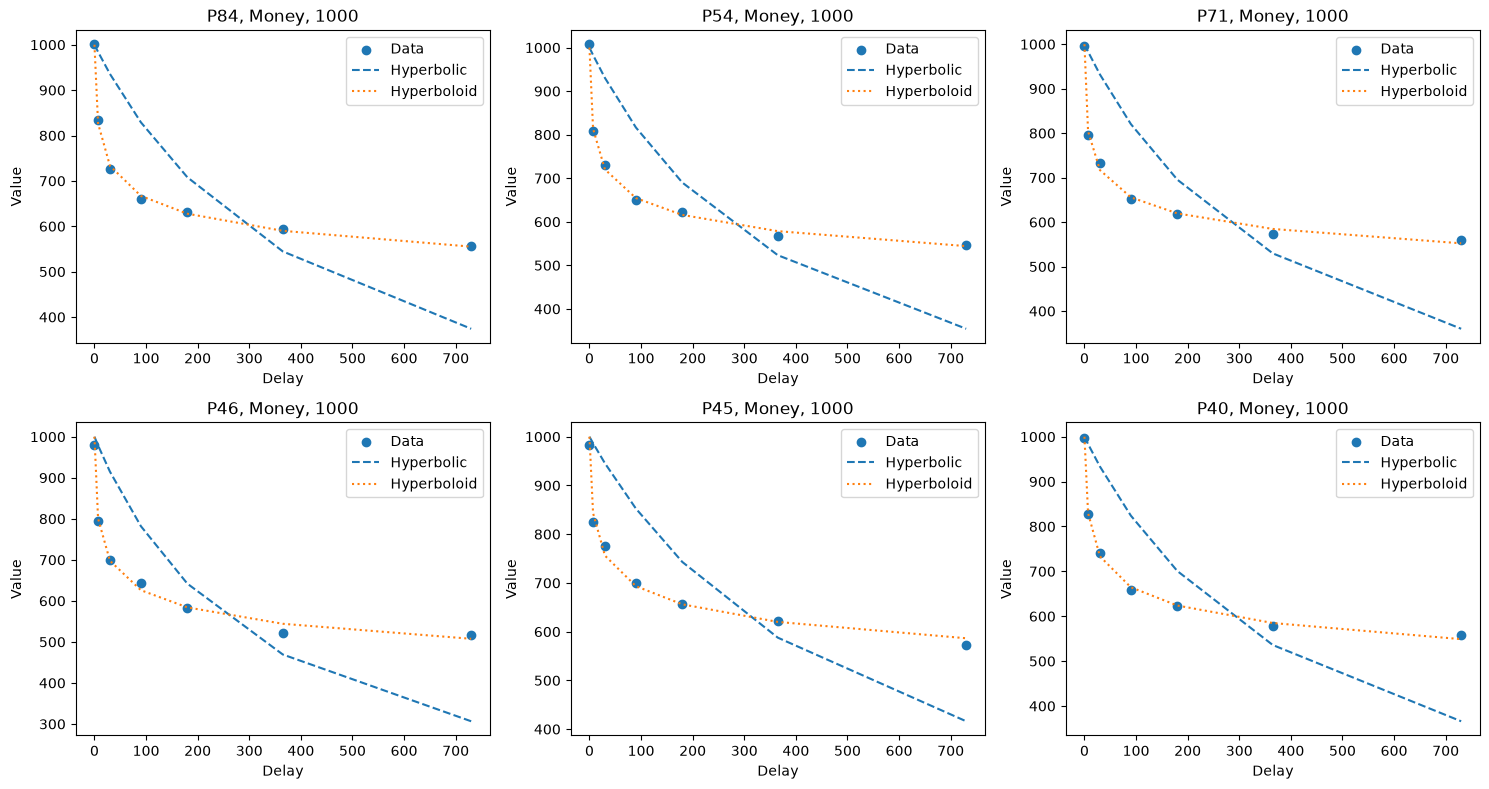

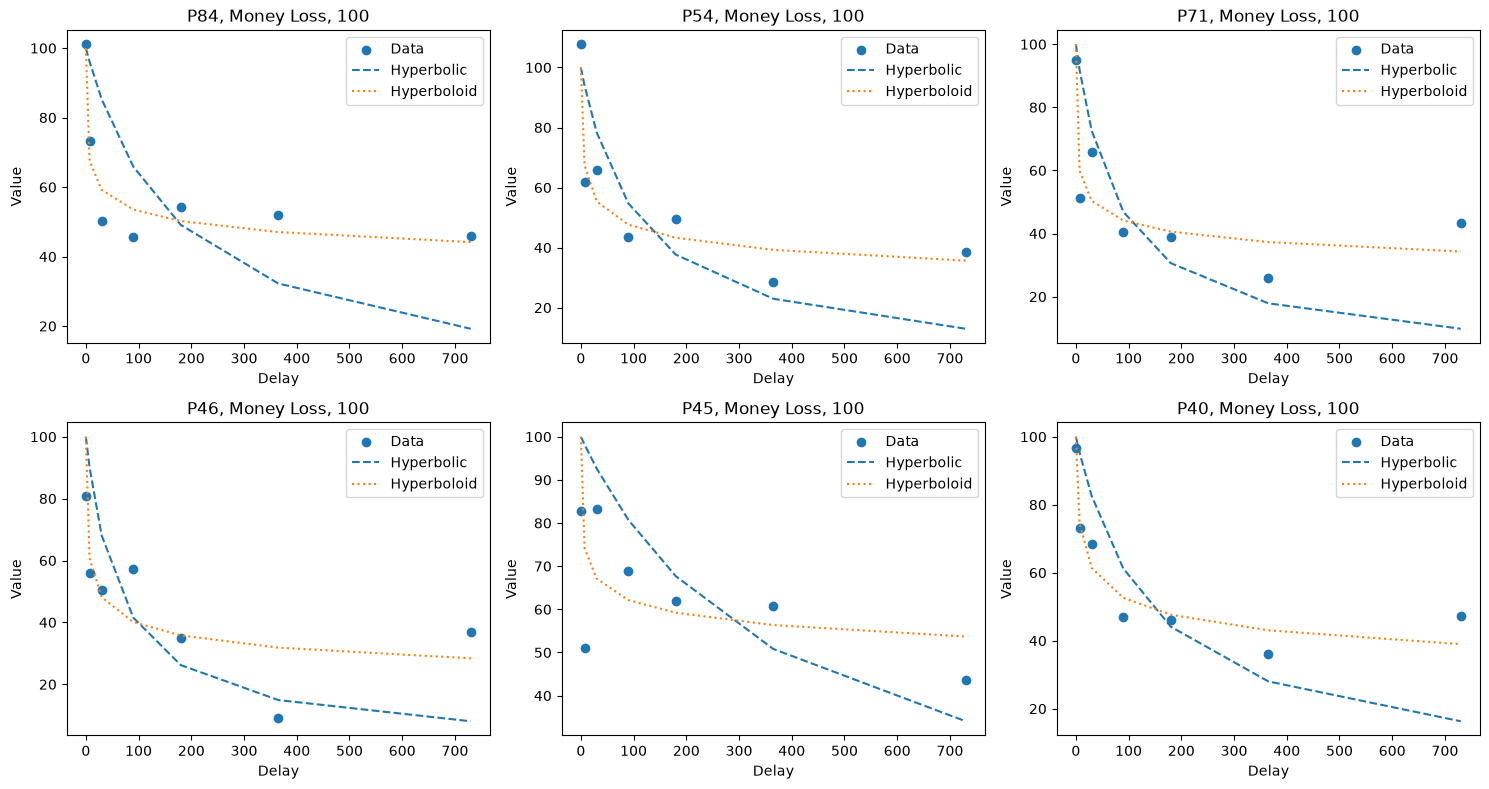

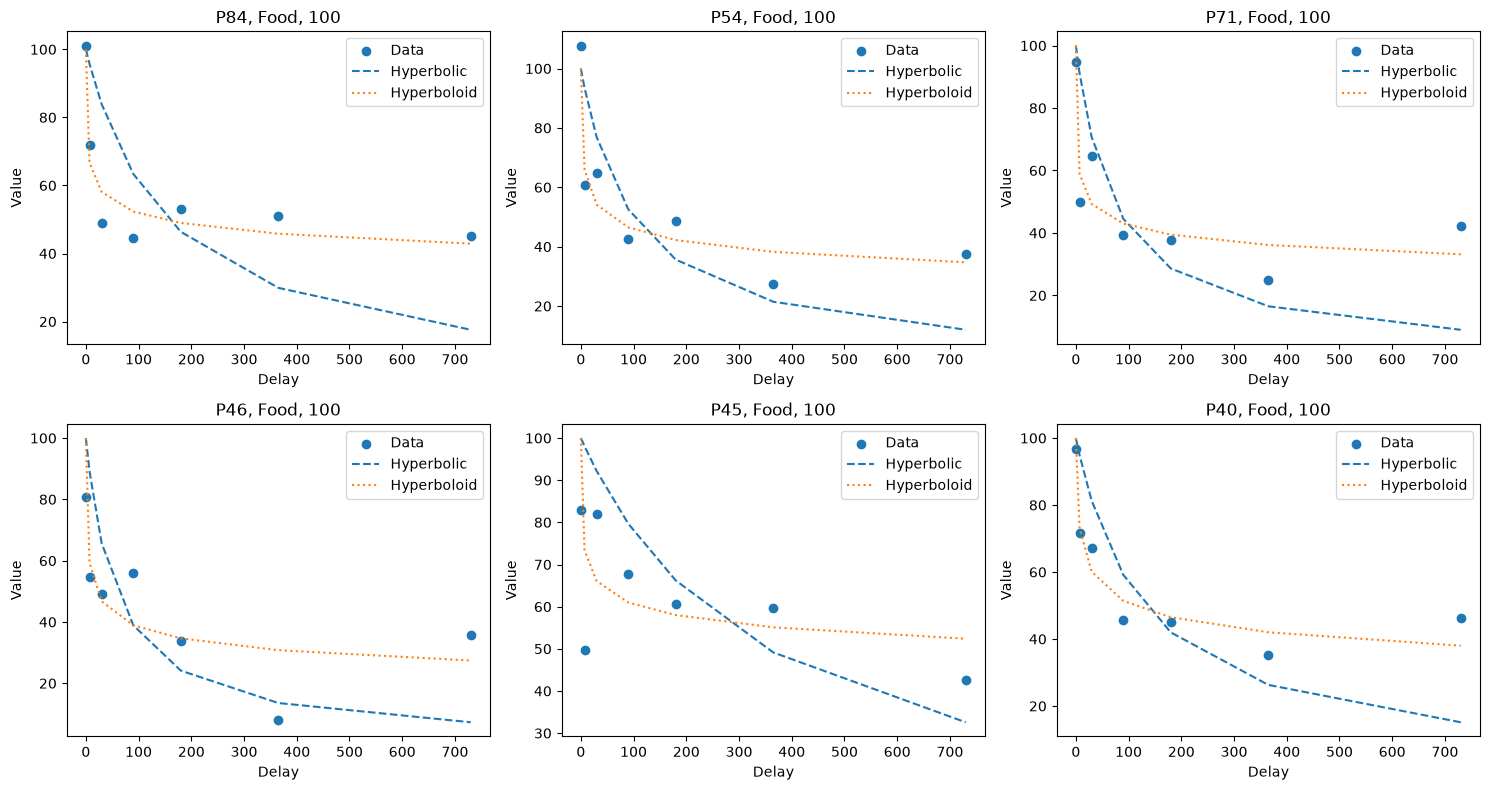

In [6]:
plot_discounting_fits(df, fit_df, commodity='Money', amount=100)
plot_discounting_fits(df, fit_df, commodity='Money', amount=1000)
plot_discounting_fits(df, fit_df, commodity='Money Loss', amount=100)
plot_discounting_fits(df, fit_df, commodity='Food', amount=100)

## Task 6: Compare parameters across tasks

Compare discount rate (`k`), the hyperboloid exponent (`s`), AUC, and model R-squared across the different amount/commodity tasks.

/var/folders/zy/tc5r5pkj3qzb9kn3t8z4rrbh0000gn/T/ipykernel_45398/1287844679.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(x='Task', y='k', hue='Model', data=k_melt, dodge=True, color='k', alpha=0.4)
/var/folders/zy/tc5r5pkj3qzb9kn3t8z4rrbh0000gn/T/ipykernel_45398/1287844679.py:35: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(x='Task', y='r2', hue='Model', data=r2_melt, dodge=True, color='k', alpha=0.4)


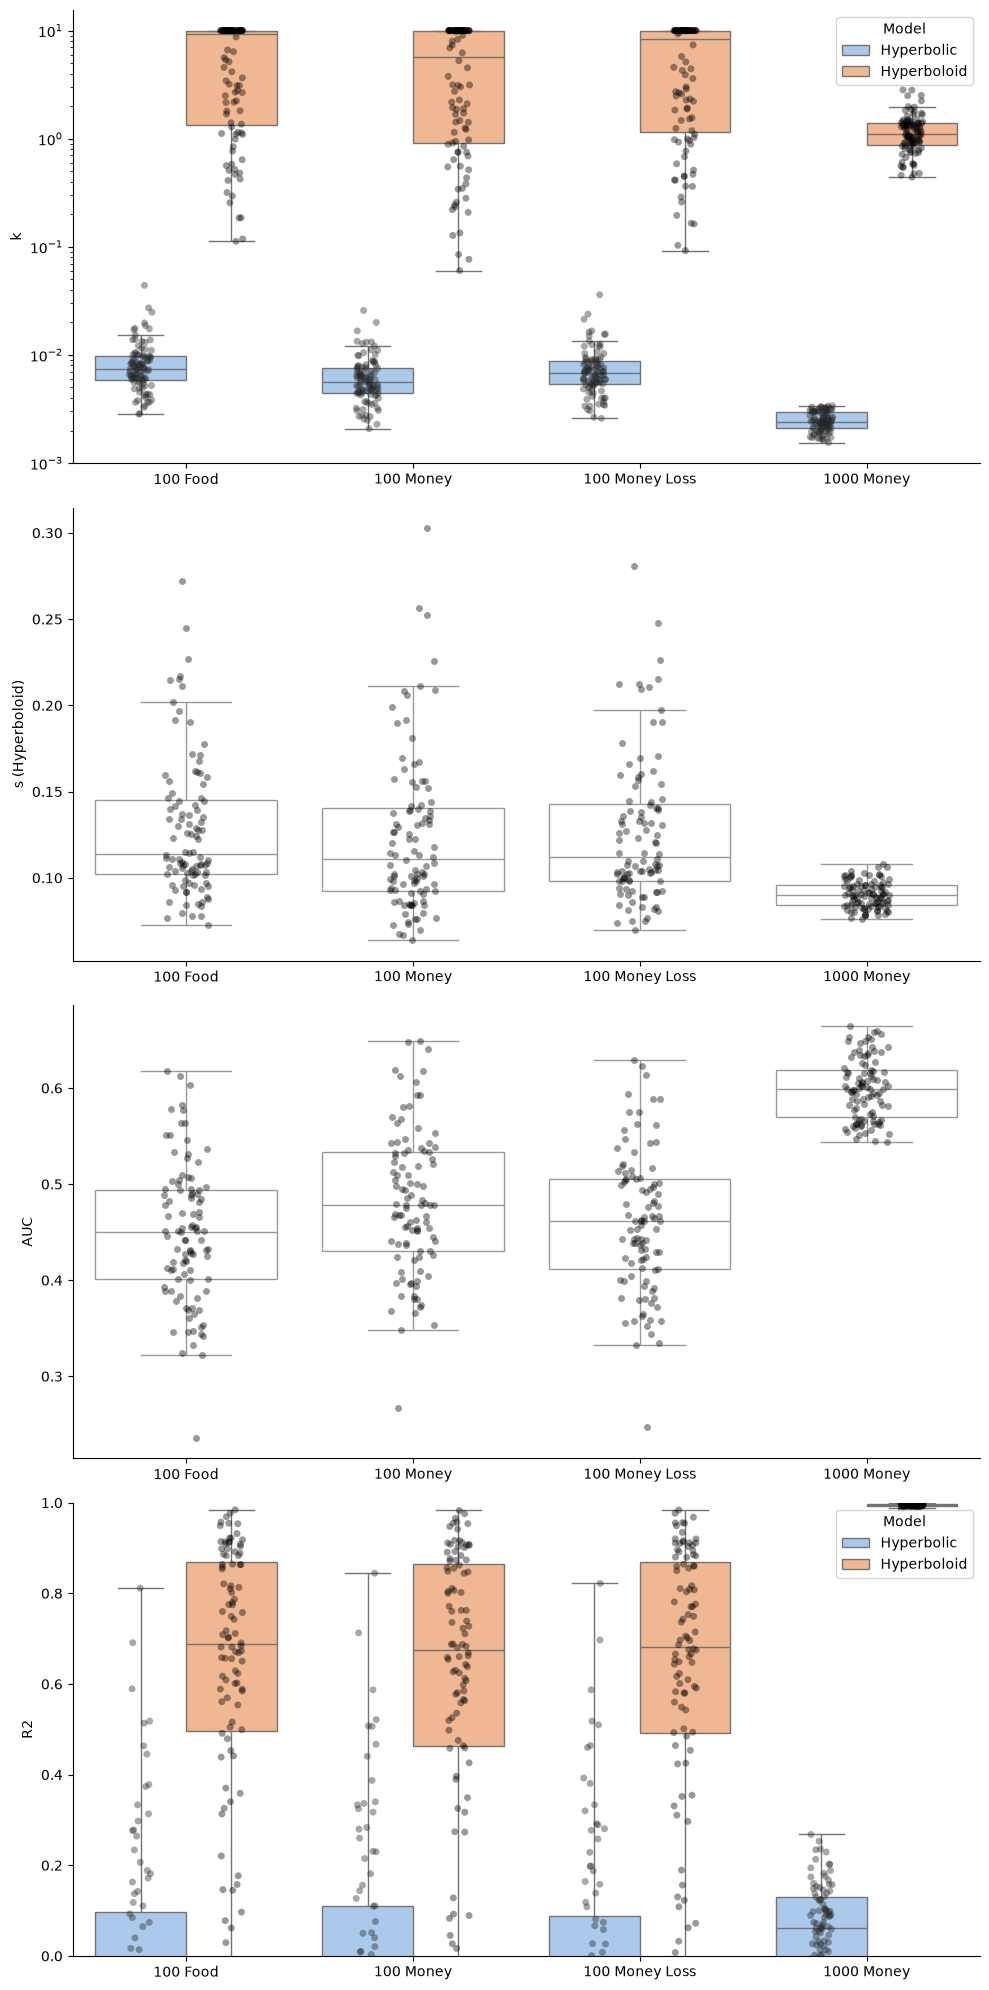

In [7]:
fit_df['Task'] = fit_df['Amount'].astype(str) + ' ' + fit_df['Commodity']

k_melt = pd.melt(fit_df, id_vars=['participant_id', 'Task'],
                 value_vars=['k_hyperbolic', 'k_hyperboloid'], var_name='Model', value_name='k')
k_melt['Model'] = k_melt['Model'].map({'k_hyperbolic': 'Hyperbolic', 'k_hyperboloid': 'Hyperboloid'})

r2_melt = pd.melt(fit_df, id_vars=['participant_id', 'Task'],
                  value_vars=['r2_hyperbolic', 'r2_hyperboloid'], var_name='Model', value_name='r2')
r2_melt['Model'] = r2_melt['Model'].map({'r2_hyperbolic': 'Hyperbolic', 'r2_hyperboloid': 'Hyperboloid'})

plt.figure(figsize=(10, 20))

plt.subplot(4, 1, 1)
sns.boxplot(x='Task', y='k', hue='Model', data=k_melt, showfliers=False, dodge=True, palette='pastel')
sns.stripplot(x='Task', y='k', hue='Model', data=k_melt, dodge=True, color='k', alpha=0.4)
plt.ylabel('k'); plt.xlabel(''); plt.yscale('log')
sns.despine(top=True, right=True)
h, l = plt.gca().get_legend_handles_labels()
plt.legend(h[:2], l[:2], title='Model', loc='best')

plt.subplot(4, 1, 2)
sns.boxplot(x='Task', y='s_hyperboloid', data=fit_df, showfliers=False, color='w')
sns.stripplot(x='Task', y='s_hyperboloid', data=fit_df, color='k', alpha=0.4)
plt.ylabel('s (Hyperboloid)'); plt.xlabel('')
sns.despine(top=True, right=True)

plt.subplot(4, 1, 3)
sns.boxplot(x='Task', y='AUC', data=fit_df, showfliers=False, color='w')
sns.stripplot(x='Task', y='AUC', data=fit_df, color='k', alpha=0.4)
plt.ylabel('AUC'); plt.xlabel('')
sns.despine(top=True, right=True)

plt.subplot(4, 1, 4)
sns.boxplot(x='Task', y='r2', hue='Model', data=r2_melt, showfliers=False, dodge=True, palette='pastel')
sns.stripplot(x='Task', y='r2', hue='Model', data=r2_melt, dodge=True, color='k', alpha=0.4)
plt.ylabel('R2'); plt.xlabel(''); plt.ylim(0, 1)
h, l = plt.gca().get_legend_handles_labels()
plt.legend(h[:2], l[:2], title='Model', loc='best')
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

## Wrap-up

Interpret the trends: Does discounting (k / AUC) change with amount (a magnitude effect)? With commodity? Between gains and losses (sign effect)? Does the hyperboloid's extra parameter meaningfully improve fit over the hyperbolic?